## TAREA 2 MACHINE LEARNING
**MATIAS CCOLQUE A.**

## P1

In [ ]:
#(C)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
#Configuración
seed = 21764927

np.random.seed(seed)

n = 1000
theta_true = 0.7

# generar datos Bernoulli
X = np.random.binomial(1, theta_true, size=n)

# tamaños muestrales
k_values = [1, 5, 10, 25, 50, 100, 500, 1000]

# priors pedidos en diccionario
priors = {
    "Beta(1,1)": (1,1),
    "Beta(5,1)": (5,1),
    "Beta(1,5)": (1,5),
    "Beta(10,10)": (10,10)
}

# grid theta(500 puntos de valores de teta a evaluar)
theta_grid = np.linspace(0.001, 0.999, 500)

#Funciones auxiliares
def posterior_params(alpha, beta_prior, s, k): #Entregua los parámetros de la posterior
    return alpha + s, beta_prior + k - s

def posterior_mean(a_post, b_post):    #a_post = parametro "a" de la posterior, analogamente con b_post.
    return a_post / (a_post + b_post)

def posterior_map(a_post, b_post): #estimador map
    # si existe moda interior
    if a_post > 1 and b_post > 1:
        return (a_post - 1) / (a_post + b_post - 2)
    elif a_post <= 1 and b_post > 1:
        return 0
    elif a_post > 1 and b_post <= 1:
        return 1
    else:
        return np.nan  # doble máximo en 0 y 1

def mle_estimator(s, k):
    return s / k

def credible_interval(a_post, b_post):
    return beta.ppf([0.025, 0.975], a_post, b_post) #95% de confianza


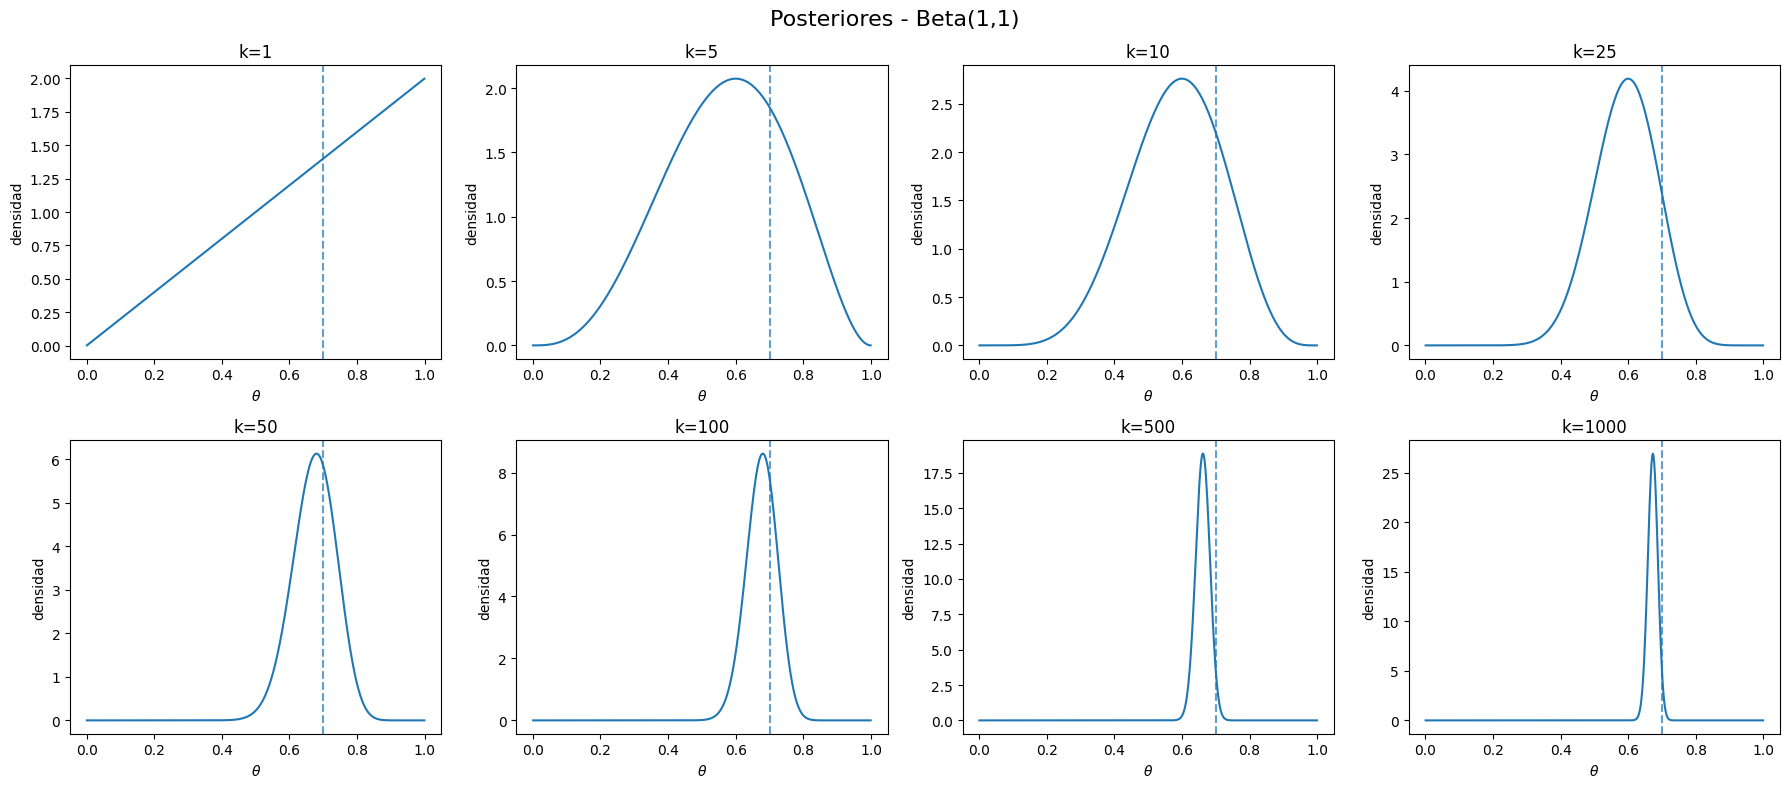

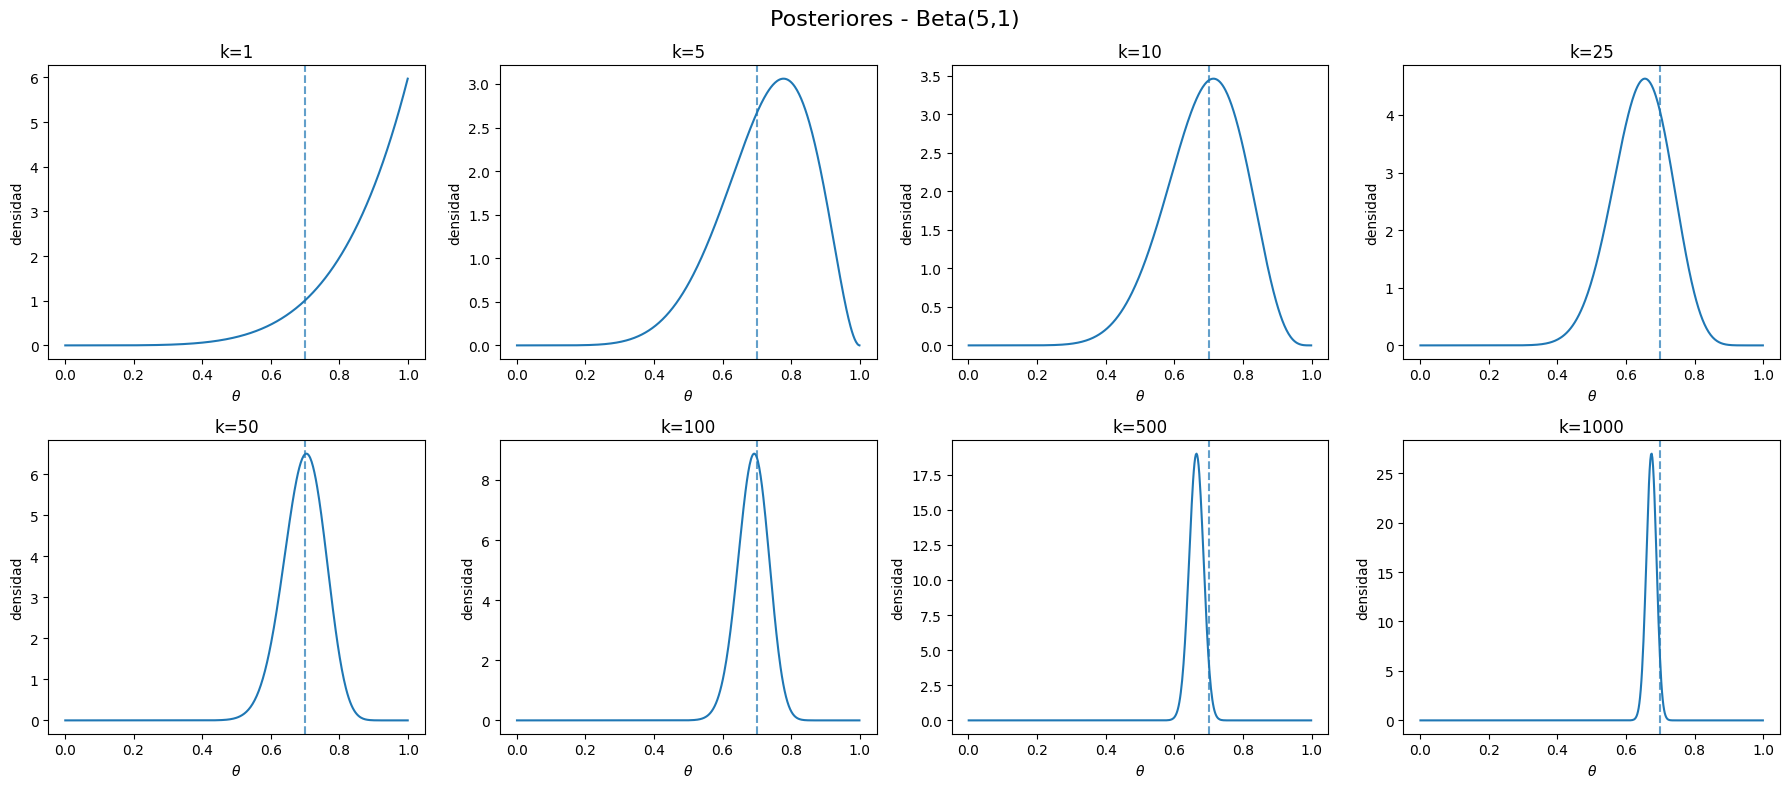

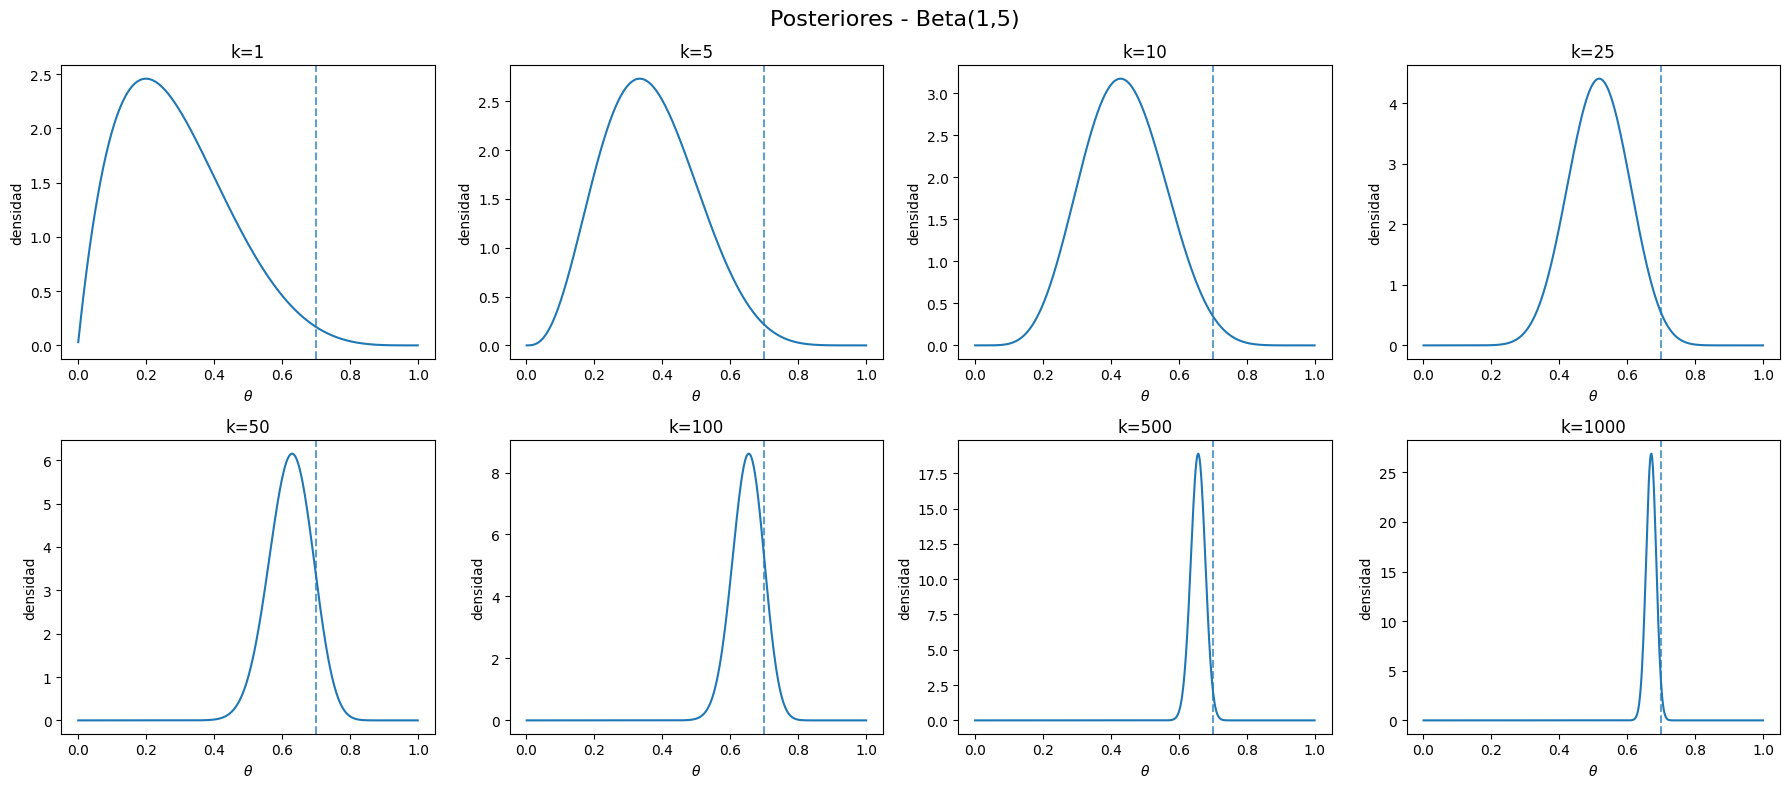

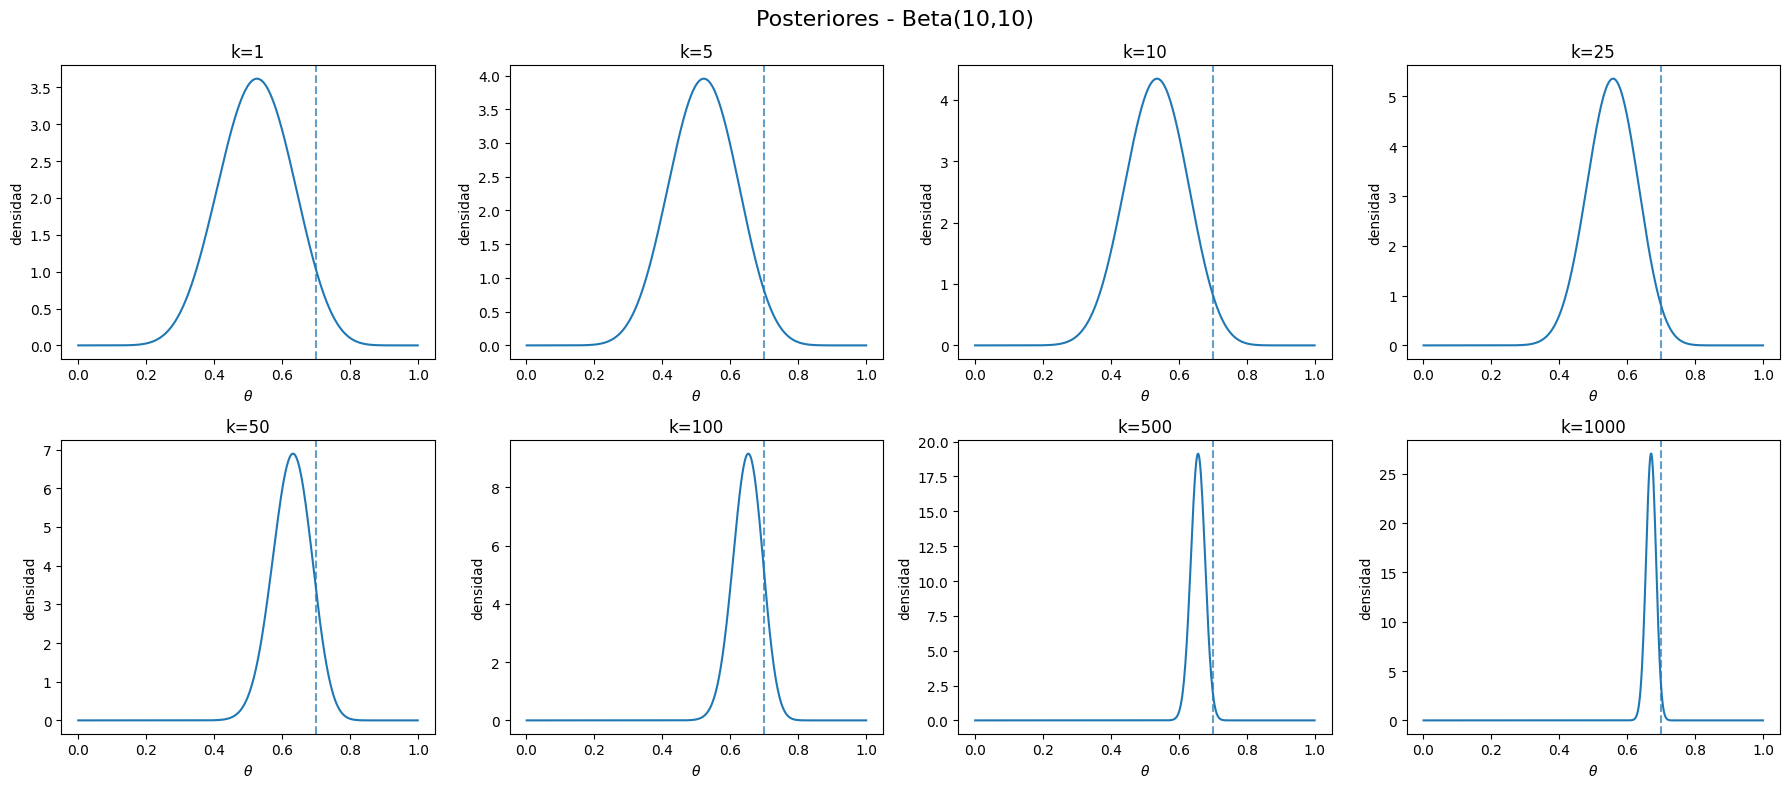

In [ ]:
#GRAFICAR POSTERIORES
for prior_name, (alpha, beta_prior) in priors.items():

    fig, axes = plt.subplots(2, 4, figsize=(18,8))
    axes = axes.flatten()

    for i, k in enumerate(k_values):

        s = np.sum(X[:k])

        a_post, b_post = posterior_params(alpha, beta_prior, s, k)

        density = beta.pdf(theta_grid, a_post, b_post)

        axes[i].plot(theta_grid, density)
        axes[i].axvline(theta_true, linestyle="--", alpha=0.7)
        axes[i].set_title(f"k={k}")
        axes[i].set_xlabel(r"$\theta$")
        axes[i].set_ylabel("densidad")

    plt.suptitle(f"Posteriores - {prior_name}", fontsize=16)
    plt.tight_layout()
    plt.show()


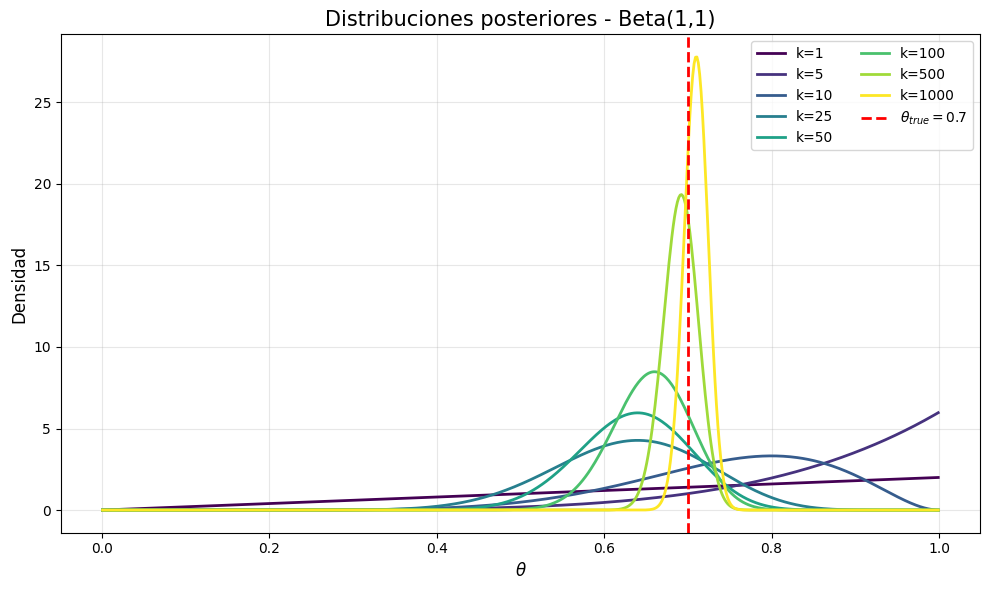

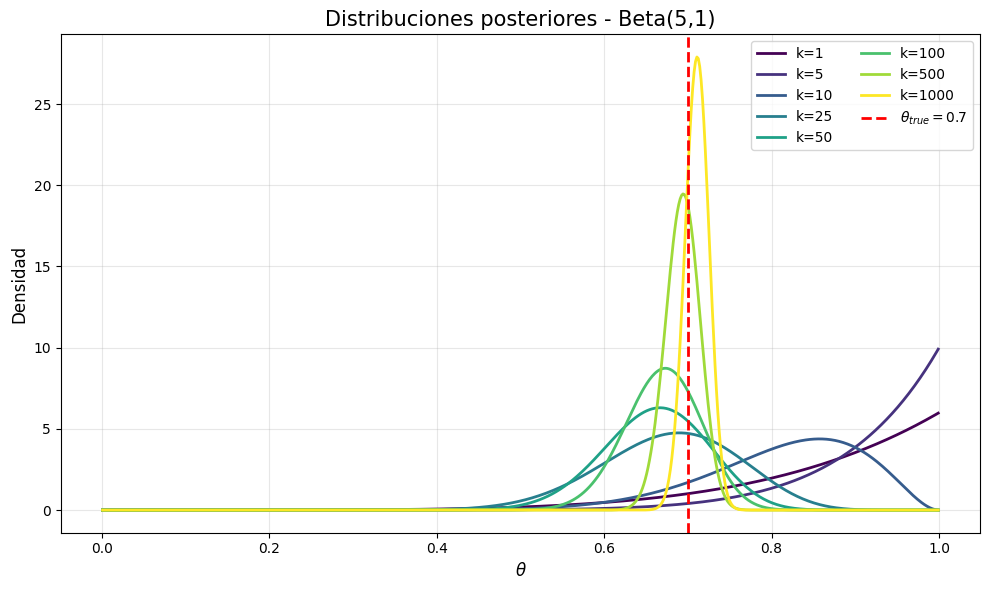

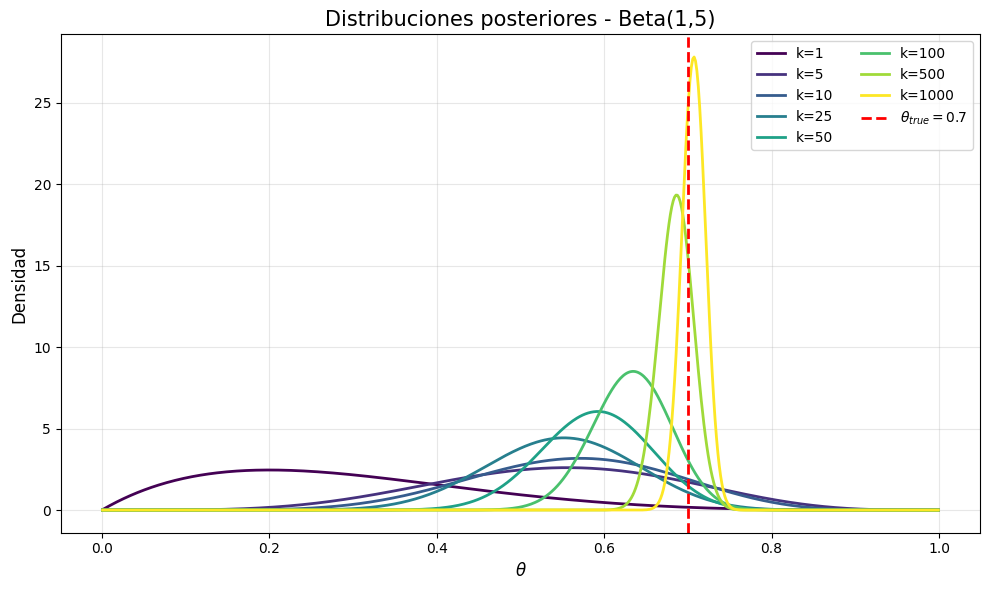

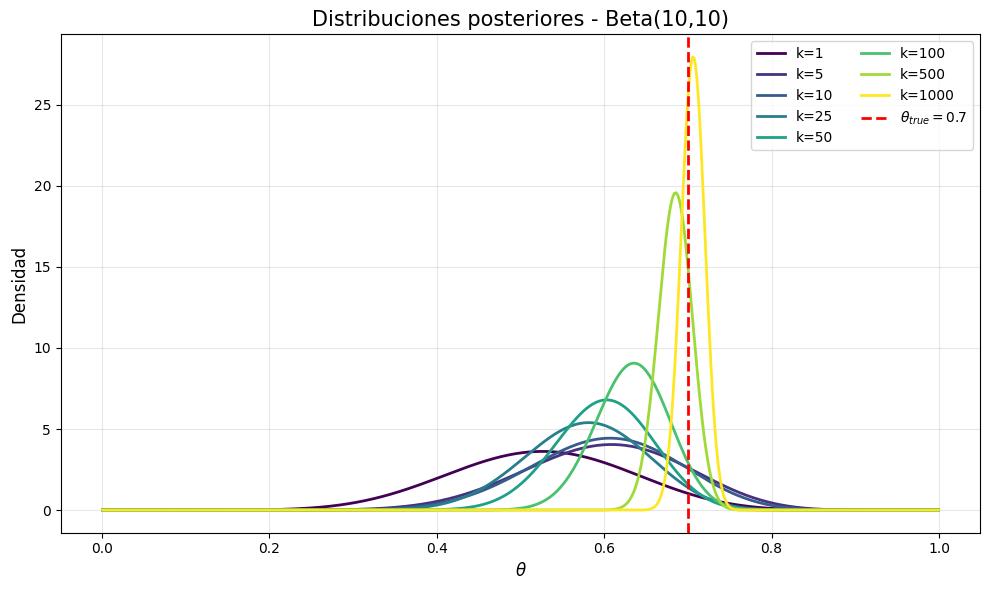

In [ ]:
#GRAFICAR POSTERIORES INTENTO 2

# ==========================================================
# GRAFICO ÚNICO POR PRIOR:
# En una sola figura aparecen las 8 posteriores (distintos k)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# --------------------------------------------
# Configuración
# --------------------------------------------
seed = 12345678   # reemplaza por tu RUT
np.random.seed(seed)

n = 1000
theta_true = 0.7

X = np.random.binomial(1, theta_true, size=n)

k_values = [1, 5, 10, 25, 50, 100, 500, 1000]

priors = {
    "Beta(1,1)": (1,1),
    "Beta(5,1)": (5,1),
    "Beta(1,5)": (1,5),
    "Beta(10,10)": (10,10)
}

theta_grid = np.linspace(0.001, 0.999, 600)

# --------------------------------------------
# Gráfico único por prior
# --------------------------------------------

for prior_name, (alpha, beta_prior) in priors.items():

    plt.figure(figsize=(10,6))

    colors = plt.cm.viridis(np.linspace(0,1,len(k_values)))

    for i, k in enumerate(k_values):

        s = np.sum(X[:k])

        a_post = alpha + s
        b_post = beta_prior + k - s

        density = beta.pdf(theta_grid, a_post, b_post)

        plt.plot(
            theta_grid,
            density,
            lw=2,
            color=colors[i],
            label=f"k={k}"
        )

    # theta real
    plt.axvline(
        theta_true,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$\theta_{true}=0.7$"
    )

    plt.title(f"Distribuciones posteriores - {prior_name}", fontsize=15)
    plt.xlabel(r"$\theta$", fontsize=12)
    plt.ylabel("Densidad", fontsize=12)
    plt.legend(fontsize=10, ncol=2)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

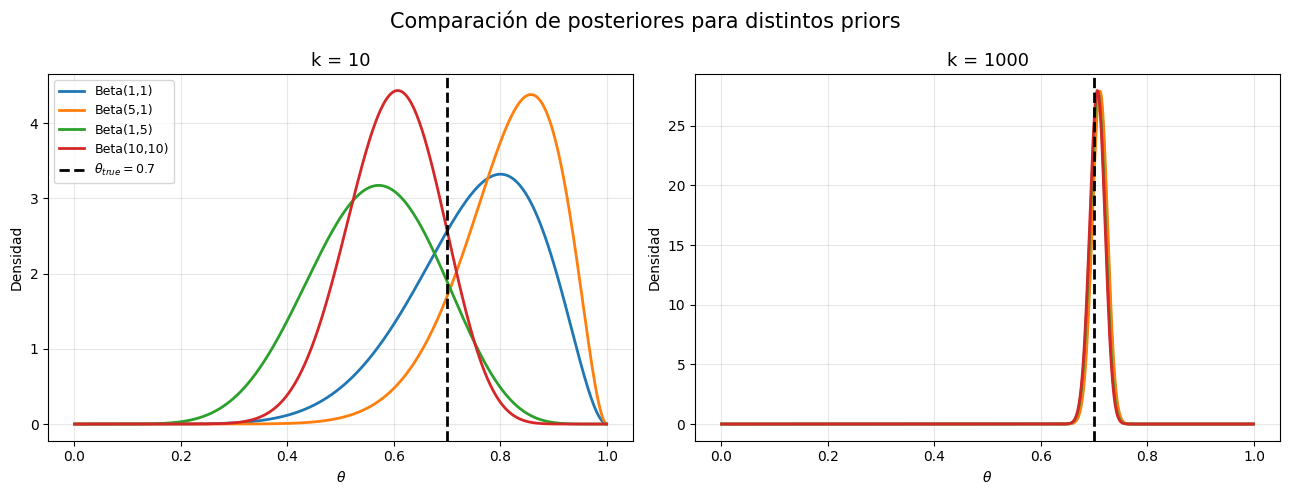

In [ ]:
#GRAFICAR POSTERIORES EN UN SOLO GRAFO INTENTO 3
#
# FIGURA 1: comparación de posteriores
# (solo bloque de plot)
#

fig, axes = plt.subplots(1, 2, figsize=(13,5))

k_values_compare = [10, 1000]

for j, k in enumerate(k_values_compare):

    ax = axes[j]
    s = np.sum(X[:k])

    for prior_name, (alpha, beta_prior) in priors.items():

        a_post = alpha + s
        b_post = beta_prior + k - s

        density = beta.pdf(theta_grid, a_post, b_post)

        ax.plot(theta_grid, density, lw=2, label=prior_name)

    ax.axvline(
        theta_true,
        color="black",
        linestyle="--",
        linewidth=2,
        label=r"$\theta_{true}=0.7$" if j == 0 else None
    )

    ax.set_title(f"k = {k}", fontsize=13)
    ax.set_xlabel(r"$\theta$")
    ax.set_ylabel("Densidad")
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=9)
plt.suptitle("Comparación de posteriores para distintos priors", fontsize=15)
plt.tight_layout()
plt.show()

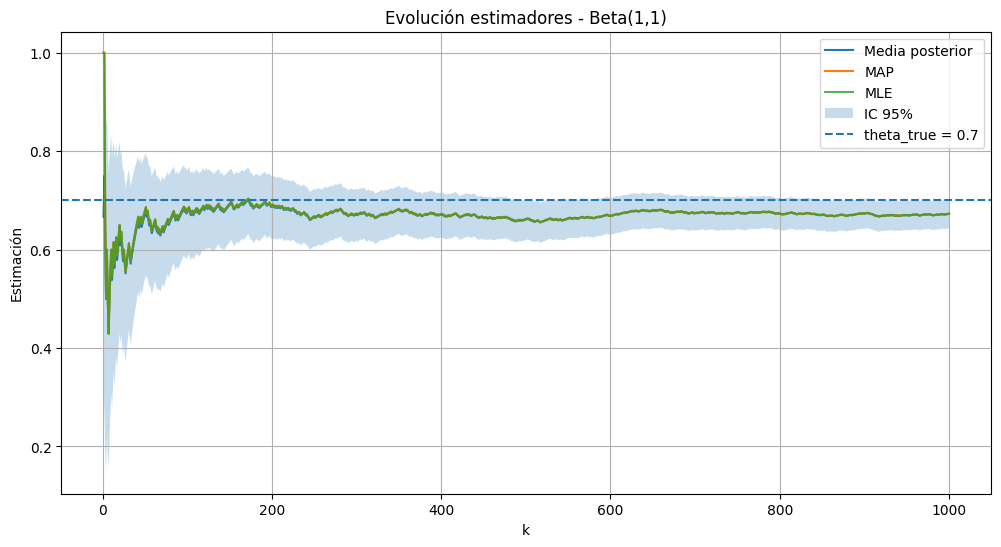

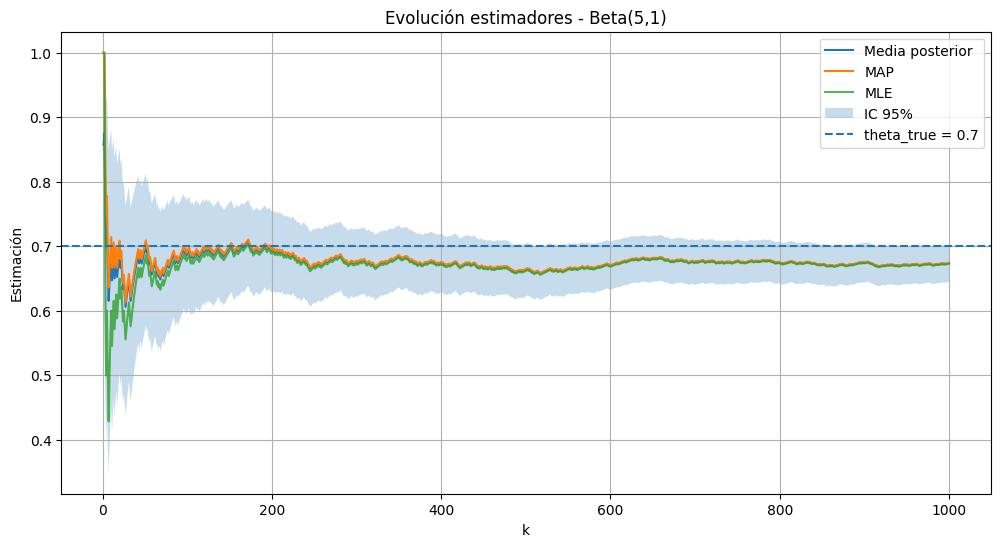

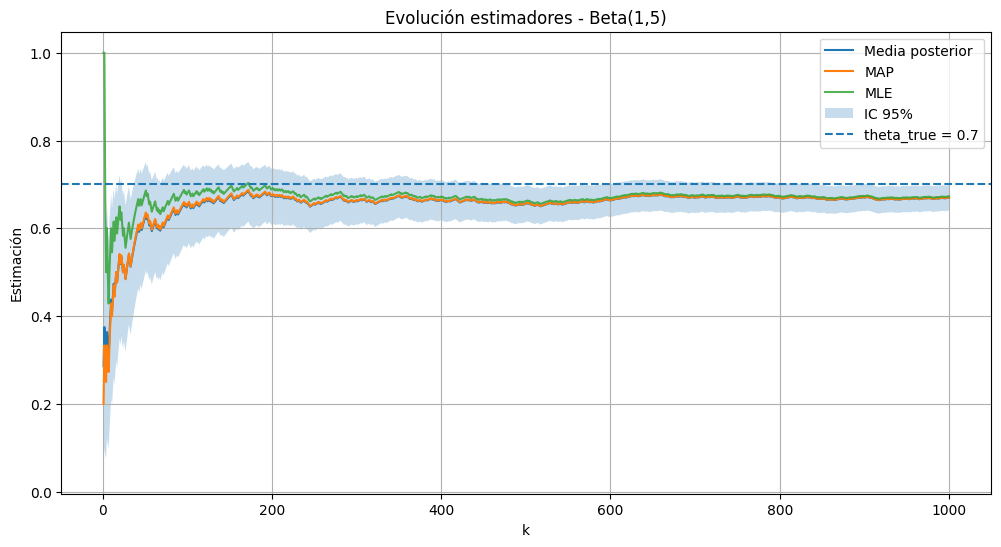

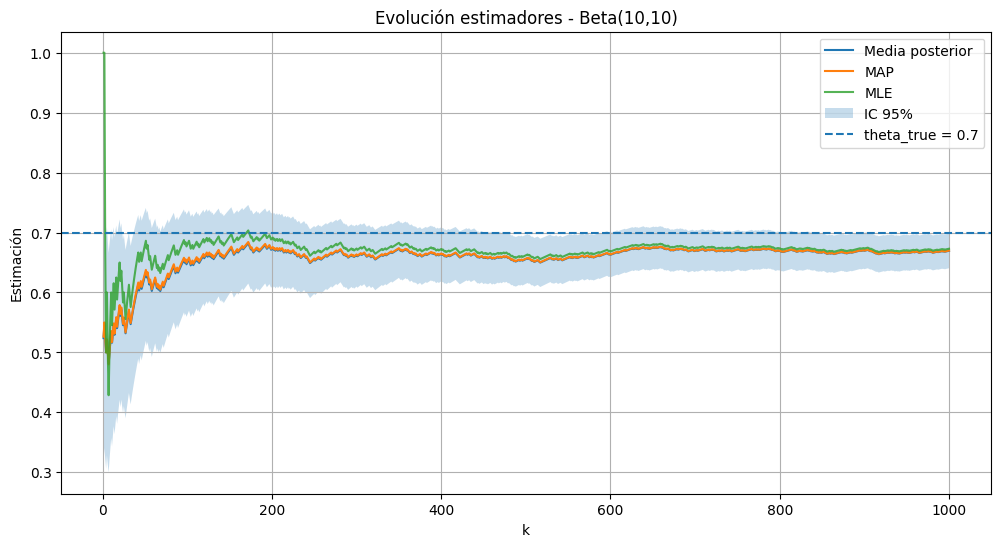

In [ ]:
# 4. EVOLUCIÓN MEDIA POSTERIOR, MAP, IC95%, MLE

for prior_name, (alpha, beta_prior) in priors.items():

    means = []
    maps = []
    mles = []
    lower = []
    upper = []

    ks = np.arange(1, n+1)

    for k in ks:

        s = np.sum(X[:k])

        a_post, b_post = posterior_params(alpha, beta_prior, s, k)

        means.append(posterior_mean(a_post, b_post))
        maps.append(posterior_map(a_post, b_post))
        mles.append(mle_estimator(s, k))

        ci = credible_interval(a_post, b_post)
        lower.append(ci[0])
        upper.append(ci[1])

    plt.figure(figsize=(12,6))

    plt.plot(ks, means, label="Media posterior")
    plt.plot(ks, maps, label="MAP")
    plt.plot(ks, mles, label="MLE", alpha=0.8)

    plt.fill_between(ks, lower, upper, alpha=0.25, label="IC 95%")

    plt.axhline(theta_true, linestyle="--", label="theta_true = 0.7")

    plt.title(f"Evolución estimadores - {prior_name}")
    plt.xlabel("k")
    plt.ylabel("Estimación")
    plt.legend()
    plt.grid(True)
    plt.show()


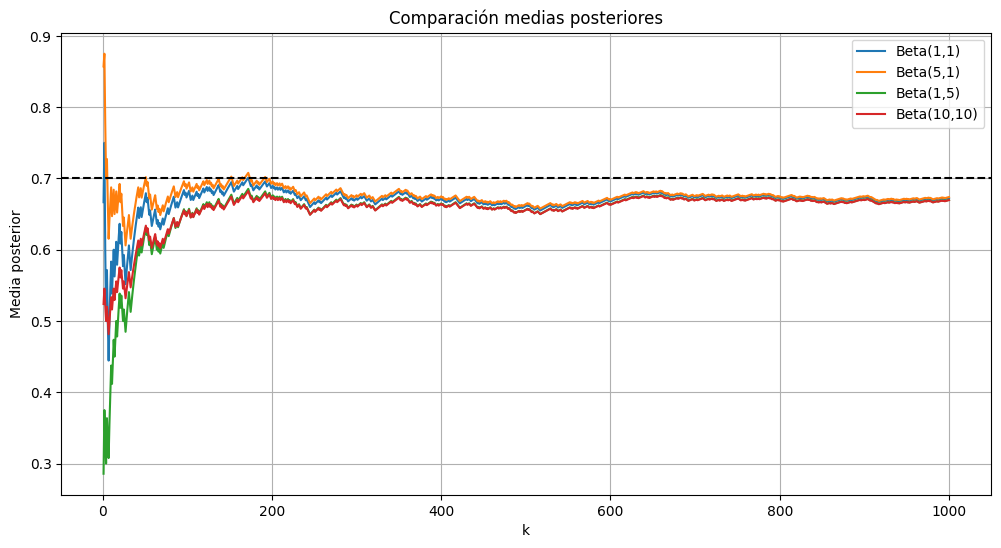

In [ ]:
# 5. COMPARACIÓN ENTRE PRIORS

plt.figure(figsize=(12,6))

for prior_name, (alpha, beta_prior) in priors.items():

    means = []

    for k in range(1, n+1):
        s = np.sum(X[:k])
        a_post, b_post = posterior_params(alpha, beta_prior, s, k)
        means.append(posterior_mean(a_post, b_post))

    plt.plot(range(1,n+1), means, label=prior_name)

plt.axhline(theta_true, linestyle="--", color="black")
plt.title("Comparación medias posteriores")
plt.xlabel("k")
plt.ylabel("Media posterior")
plt.legend()
plt.grid(True)
plt.show()

# **P2**

In [ ]:
#SUBIDA DE ARCHIVO
from google.colab import files
uploaded = files.upload()

Saving data_t2_p2.json to data_t2_p2 (1).json


In [ ]:
#Lectura del archivo
import json
file_lec = list(uploaded.keys())[0]
with open(file_lec, "r", encoding="utf-8") as f:
    data = json.load(f)

In [ ]:
#paquetes necesarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#conversión dataframes
daily_df   = pd.DataFrame(data["daily"]["data"])
weekly_df  = pd.DataFrame(data["weekly"]["data"])
monthly_df = pd.DataFrame(data["monthly"]["data"])
#fechas
daily_df["date"] = pd.to_datetime(daily_df["date"])
weekly_df["week_start"] = pd.to_datetime(weekly_df["week_start"])
weekly_df["week_end"]   = pd.to_datetime(weekly_df["week_end"])
monthly_df["date"] = pd.to_datetime(monthly_df["date"])

In [ ]:
#INFORMACIÓN BÁSICA(cantidad filas, cantidadcolumnas)
print("Daily shape:  ", daily_df.shape)
print("Weekly shape: ", weekly_df.shape)
print("Monthly shape:", monthly_df.shape)
#A medida que va siendo más general posee más información(columnas) que mencionar
print("\nPrimeras filas monthly:")
print(monthly_df.head())

Daily shape:   (5294, 3)
Weekly shape:  (757, 4)
Monthly shape: (174, 5)

Primeras filas monthly:
   index  year  month       date  review_count
0      1  2009      1 2009-01-01            27
1      2  2009      2 2009-02-01             5
2      3  2009      3 2009-03-01             8
3      4  2009      4 2009-04-01             4
4      5  2009      5 2009-05-01             8


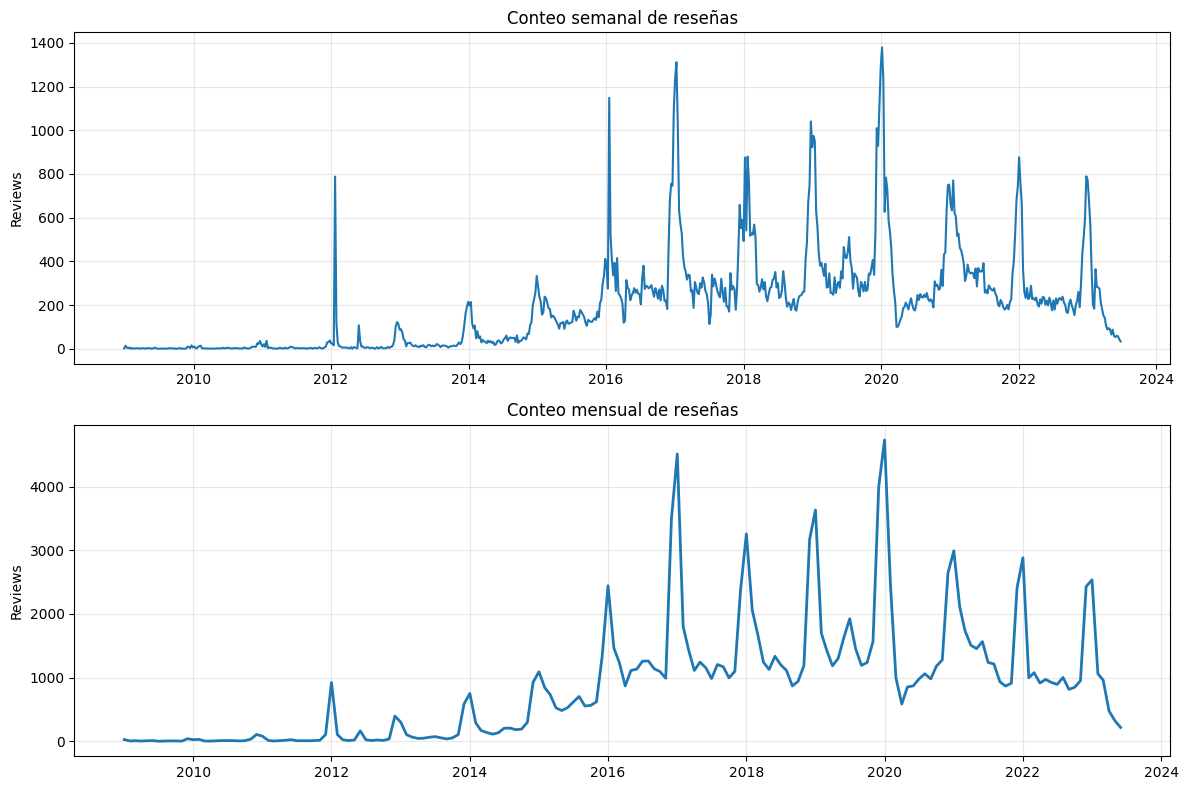

In [ ]:
#Visualización 2 granularidades
fig, ax = plt.subplots(2,1, figsize=(12,8))

# Weekly
ax[0].plot(weekly_df["week_start"], weekly_df["review_count"], lw=1.5)
ax[0].set_title("Conteo semanal de reseñas")
ax[0].set_ylabel("Reviews")
ax[0].grid(alpha=0.3)

# Monthly
ax[1].plot(monthly_df["date"], monthly_df["review_count"], lw=2)
ax[1].set_title("Conteo mensual de reseñas")
ax[1].set_ylabel("Reviews")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#ELECCION: MONTHLY
df = monthly_df.copy()
x = df["index"].values
y = df["review_count"].values
#entrenamiento
n = len(df)
split = int(0.75 * n)

x_train = x[:split]
y_train = y[:split]

x_test = x[split:]
y_test = y[split:]

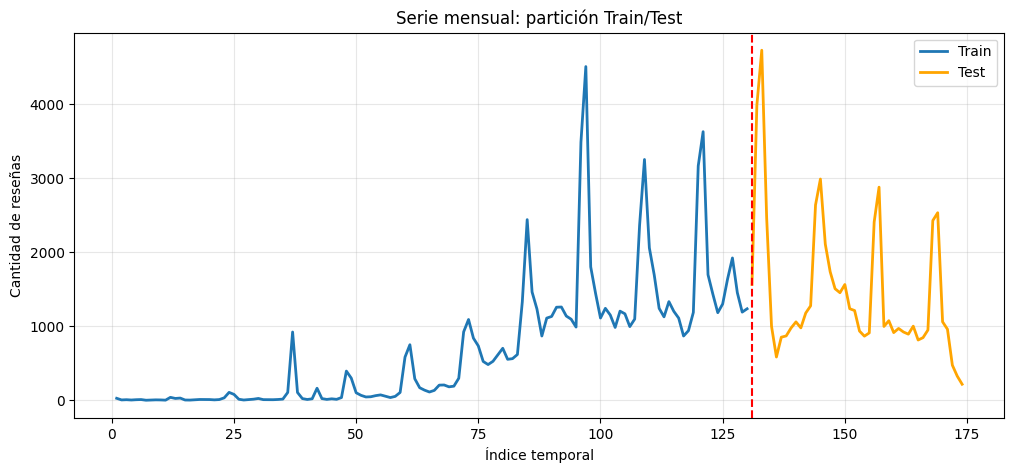

Total observaciones: 174
Train: 130
Test : 44


In [ ]:
#grafo del entrenamiento
plt.figure(figsize=(12,5))

plt.plot(x_train, y_train, label="Train", lw=2)
plt.plot(x_test, y_test, label="Test", lw=2, color="orange")

plt.axvline(x[split], linestyle="--", color="red") #PUNTO DONDE TERMINA EL ENTRENAMIENTO Y EMPIEZA LA PRUEBA DE PREDICCIÓN DEL FUTURO

plt.title("Serie mensual: partición Train/Test")
plt.xlabel("Índice temporal")
plt.ylabel("Cantidad de reseñas")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
#mini resumen
print("Total observaciones:", n)
print("Train:", len(x_train))
print("Test :", len(x_test))

**(2)**

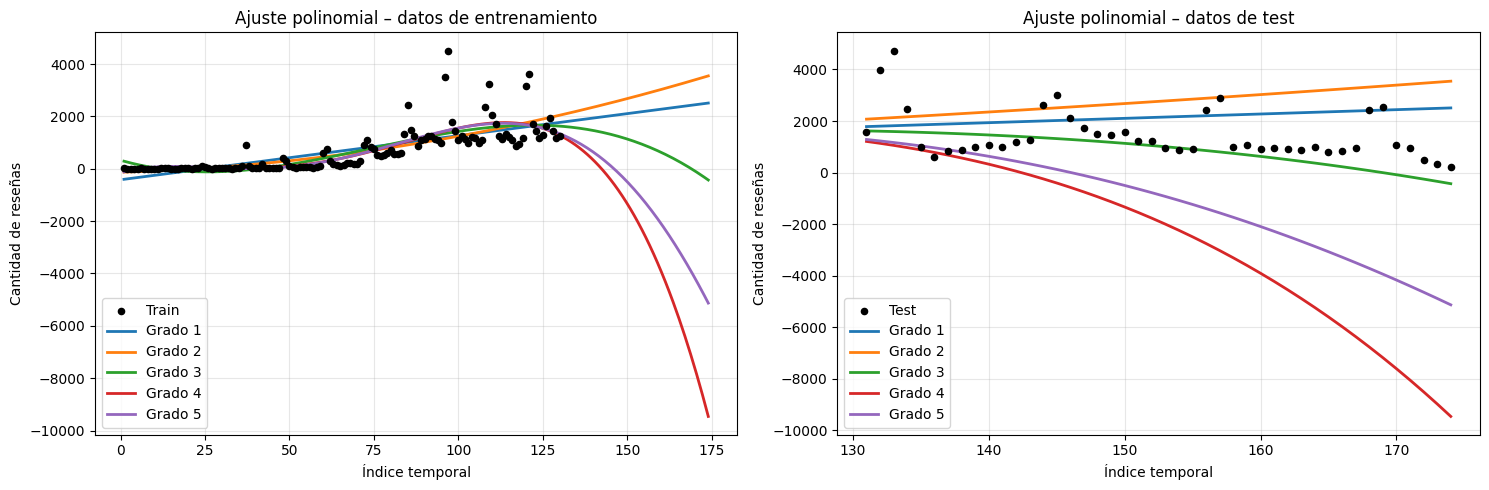

In [ ]:
# AJUSTE POLINOMIAL GRADO 1 AL 5

grados = [1, 2, 3, 4, 5]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

# Normalizar x usando stats del train (PARA EVITAR DIVERGENCIA)
x_mean = x_train.mean()
x_std  = x_train.std()

x_train_norm = (x_train - x_mean) / x_std
x_test_norm  = (x_test  - x_mean) / x_std

# Rango para graficar suavemente
x_plot      = np.linspace(x.min(), x.max(), 300)
x_plot_norm = (x_plot - x_mean) / x_std

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel izquierdo, ajuste sobre datos de ENTRENAMIENTO
axes[0].scatter(x_train, y_train, color='black', s=20, label='Train', zorder=5)
for grado, color in zip(grados, colors):
    coefs = np.polyfit(x_train_norm, y_train, grado)
    poly  = np.poly1d(coefs)
    axes[0].plot(x_plot, poly(x_plot_norm), lw=2, color=color, label=f'Grado {grado}')

axes[0].set_title('Ajuste polinomial – datos de entrenamiento')
axes[0].set_xlabel('Índice temporal')
axes[0].set_ylabel('Cantidad de reseñas')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel derecho, evaluación sobre datos de TEST
axes[1].scatter(x_test, y_test, color='black', s=20, label='Test', zorder=5)
for grado, color in zip(grados, colors):
    coefs = np.polyfit(x_train_norm, y_train, grado)
    poly  = np.poly1d(coefs)
    axes[1].plot(x_test, poly(x_test_norm), lw=2, color=color, label=f'Grado {grado}')

axes[1].set_title('Ajuste polinomial – datos de test')
axes[1].set_xlabel('Índice temporal')
axes[1].set_ylabel('Cantidad de reseñas')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#MÉTRICAS POR GRADO POLINOMIAL

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

def msle(y_true, y_pred):
    y_pred_clipped = np.maximum(y_pred, 0)
    return np.mean((np.log1p(y_true) - np.log1p(y_pred_clipped))**2)

resultados = []

for grado in grados:
    coefs = np.polyfit(x_train_norm, y_train, grado)
    poly  = np.poly1d(coefs)

    y_pred_test = poly(x_test_norm)

    ecm  = mean_squared_error(y_test, y_pred_test)
    eam  = mean_absolute_error(y_test, y_pred_test)
    r2   = r2_score(y_test, y_pred_test)
    msle_val = msle(y_test, y_pred_test)

    resultados.append({
        'Grado': grado,
        'ECM':   round(ecm, 2),
        'EAM':   round(eam, 2),
        'R2':    round(r2, 4),
        'MSLE':  round(msle_val, 4)
    })

df_resultados = pd.DataFrame(resultados).set_index('Grado')
print(df_resultados.to_string())

               ECM      EAM       R2     MSLE
Grado                                        
1       1556828.27  1088.08  -0.8107   0.7404
2       3150882.80  1585.33  -2.6647   1.1340
3       1140189.18   781.05  -0.3261   6.5273
4      25497035.36  4114.14 -28.6552  36.8711
5      10349483.68  2690.91 -11.0373  32.3382


**(5)**

Init 1: loss=34233926.22 | params=[ 3.440942e+02  2.612900e+00 -8.200000e-01  9.210000e-02] | success=False
Init 2: loss=34233926.22 | params=[-3.440927e+02  2.612900e+00  2.321600e+00  9.210000e-02] | success=False
Init 3: loss=34233926.22 | params=[ 3.440912e+02  2.612900e+00 -8.200000e-01  9.210000e-02] | success=False
Init 4: loss=34233926.22 | params=[-3.440936e+02  2.612900e+00  2.321600e+00  9.210000e-02] | success=False
Init 5: loss=34233926.22 | params=[3.440936e+02 2.612900e+00 5.463200e+00 9.210000e-02] | success=False

Mejor solución (init 2): [-3.440927e+02  2.612900e+00  2.321600e+00  9.210000e-02]

ECM : 1459109.35
EAM : 975.62
R2  : -0.6971
MSLE: 0.6831


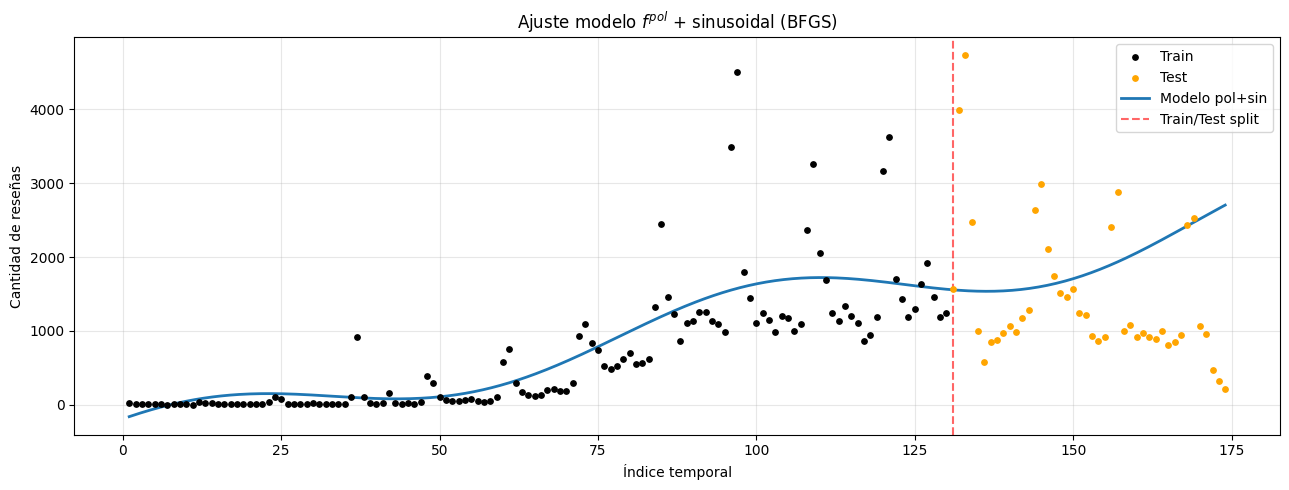

In [ ]:
# AJUSTE MODELO POL + SINUSOIDAL CON MLE

from scipy.optimize import minimize

# Fijar f_pol (grado 1, entrenado con x normalizado)
coefs_pol = np.polyfit(x_train_norm, y_train, 1)
f_pol     = np.poly1d(coefs_pol)

# Definir el modelo completo
def modelo(x_norm, params):
    t1, t2, t3, t4 = params
    return f_pol(x_norm) + t1 * np.sin(t2 * x_norm + t3) * np.exp(t4 * x_norm)

# Función de pérdida
def neg_log_likelihood(params):
    y_pred = modelo(x_train_norm, params)
    residuos = y_train - y_pred
    return np.sum(residuos**2)

# Optimización con BFGS desde distintas condiciones iniciales
iniciales = [
    [500,  0.5,  0.0,  0.01],
    [1000, 1.0,  1.0,  0.01],
    [200,  0.3, -1.0,  0.01],
    [-500, 0.5,  0.0,  0.01],
    [500,  2.0,  3.14, 0.01],
]

resultados_opt = []
for i, theta0 in enumerate(iniciales):
    res = minimize(neg_log_likelihood, theta0, method='BFGS',
                   options={'maxiter': 10000, 'gtol': 1e-8})
    resultados_opt.append({
        'init': i+1,
        'params': res.x,
        'loss': res.fun,
        'success': res.success
    })
    print(f"Init {i+1}: loss={res.fun:.2f} | params={np.round(res.x,4)} | success={res.success}")

# Seleccionar la mejor solución (menor pérdida)
mejor = min(resultados_opt, key=lambda r: r['loss'])
theta_opt = mejor['params']
print(f"\nMejor solución (init {mejor['init']}): {np.round(theta_opt, 4)}")

# Métricas en TEST
y_pred_test = modelo(x_test_norm, theta_opt)

ecm_val  = mean_squared_error(y_test, y_pred_test)
eam_val  = mean_absolute_error(y_test, y_pred_test)
r2_val   = r2_score(y_test, y_pred_test)
msle_val = msle(y_test, y_pred_test)

print(f"\nECM : {ecm_val:.2f}")
print(f"EAM : {eam_val:.2f}")
print(f"R2  : {r2_val:.4f}")
print(f"MSLE: {msle_val:.4f}")

# GRAFO AJUSTE
plt.figure(figsize=(13, 5))

plt.scatter(x_train, y_train, color='black', s=15, label='Train', zorder=5)
plt.scatter(x_test,  y_test,  color='orange', s=15, label='Test',  zorder=5)

x_plot_all      = np.linspace(x.min(), x.max(), 500)
x_plot_all_norm = (x_plot_all - x_mean) / x_std

plt.plot(x_plot_all, modelo(x_plot_all_norm, theta_opt),
         color='tab:blue', lw=2, label='Modelo pol+sin')
plt.axvline(x[split], linestyle='--', color='red', alpha=0.6, label='Train/Test split')

plt.title('Ajuste modelo $f^{pol}$ + sinusoidal (BFGS)')
plt.xlabel('Índice temporal')
plt.ylabel('Cantidad de reseñas')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**(6)**


── BFGS ──
  success : False
  loss    : 33753761.1495
  params  : [ 6.860051e+02 -7.550000e-02 -1.129000e-01 -8.350000e-01]
  n_iter  : 92
  n_feval : 710

── Nelder-Mead ──
  success : True
  loss    : 33753615.8225
  params  : [-2.24675913e+05  2.00000000e-04  3.00000000e-04 -8.38800000e-01]
  n_iter  : 16776
  n_feval : 27313

── L-BFGS-B ──
  success : True
  loss    : 33754394.9257
  params  : [ 2.999894e+02 -1.740000e-01 -2.606000e-01 -8.188000e-01]
  n_iter  : 17
  n_feval : 100

Mejor método: Nelder-Mead
Parámetros  : [-2.24675913e+05  2.00000000e-04  3.00000000e-04 -8.38800000e-01]

ECM : 1440939.62
EAM : 964.01
R2  : -0.6759
MSLE: 0.6741

── Comparación de métodos ──
Método                     Loss   n_iter   n_feval   success
BFGS              33753761.1495       92       710     False
Nelder-Mead       33753615.8225    16776     27313      True
L-BFGS-B          33754394.9257       17       100      True


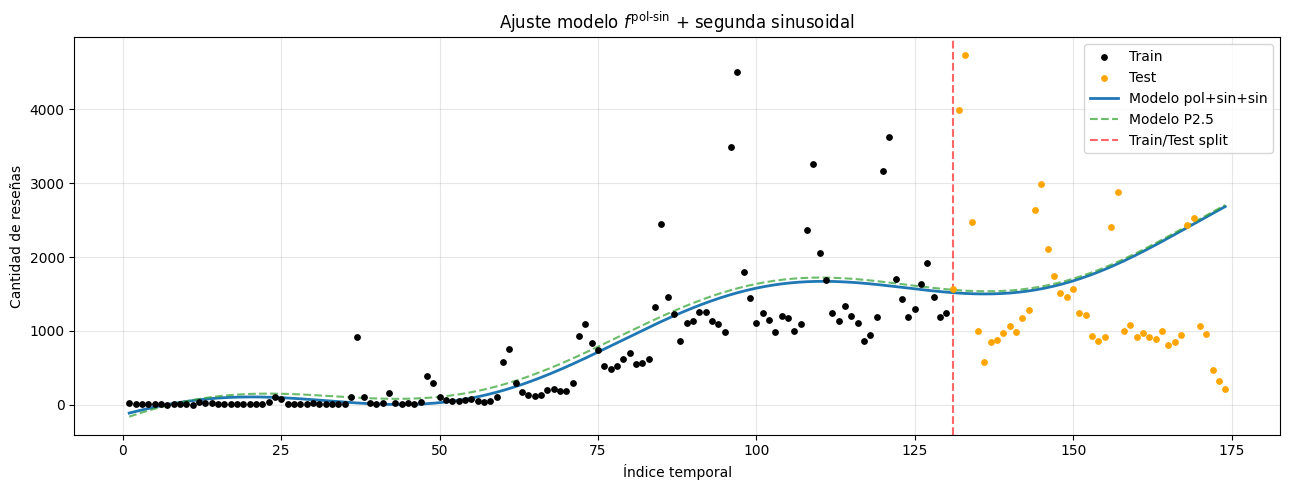

In [ ]:
# P2.6 - SEGUNDA COMPONENTE SINUSOIDAL CON MLE

# Fijar parámetros de f_pol_sin (resultado P2.5)
theta_pol_sin = theta_opt  # parámetros encontrados en P2.5

def f_pol_sin(x_norm, params=theta_pol_sin):
    t1, t2, t3, t4 = params
    return f_pol(x_norm) + t1 * np.sin(t2 * x_norm + t3) * np.exp(t4 * x_norm)

# Modelo completo con segunda sinusoidal
def modelo_completo(x_norm, params5678):
    t5, t6, t7, t8 = params5678
    return f_pol_sin(x_norm) + t5 * np.sin(t6 * x_norm + t7) * np.exp(t8 * x_norm)

# Función de pérdida (solo optimiza θ5,θ6,θ7,θ8)
def neg_log_likelihood_2(params5678):
    y_pred = modelo_completo(x_train_norm, params5678)
    residuos = y_train - y_pred
    return np.sum(residuos**2)

# Condición inicial
theta0_2 = [300, 1.0, 0.0, 0.01]

# Optimización con tres métodos
metodos = ['BFGS', 'Nelder-Mead', 'L-BFGS-B']
resultados_metodos = {}

for metodo in metodos:
    res = minimize(neg_log_likelihood_2, theta0_2, method=metodo,
                   options={'maxiter': 50000, 'gtol': 1e-8} if metodo != 'Nelder-Mead'
                   else {'maxiter': 50000, 'xatol': 1e-8, 'fatol': 1e-8})
    resultados_metodos[metodo] = res
    print(f"\n── {metodo} ──")
    print(f"  success : {res.success}")
    print(f"  loss    : {res.fun:.4f}")
    print(f"  params  : {np.round(res.x, 4)}")
    print(f"  n_iter  : {res.get('nit', 'N/A')}")
    print(f"  n_feval : {res.get('nfev', 'N/A')}")

# Seleccionar mejor solución
mejor_metodo = min(resultados_metodos, key=lambda m: resultados_metodos[m].fun)
theta_opt_2  = resultados_metodos[mejor_metodo].x
print(f"\nMejor método: {mejor_metodo}")
print(f"Parámetros  : {np.round(theta_opt_2, 4)}")

# Métricas en TEST
y_pred_test_2 = modelo_completo(x_test_norm, theta_opt_2)

ecm_2  = mean_squared_error(y_test, y_pred_test_2)
eam_2  = mean_absolute_error(y_test, y_pred_test_2)
r2_2   = r2_score(y_test, y_pred_test_2)
msle_2 = msle(y_test, y_pred_test_2)

print(f"\nECM : {ecm_2:.2f}")
print(f"EAM : {eam_2:.2f}")
print(f"R2  : {r2_2:.4f}")
print(f"MSLE: {msle_2:.4f}")

# Tabla comparativa de métodos
print("\n── Comparación de métodos ──")
print(f"{'Método':<15} {'Loss':>15} {'n_iter':>8} {'n_feval':>9} {'success':>9}")
for metodo, res in resultados_metodos.items():
    print(f"{metodo:<15} {res.fun:>15.4f} {res.get('nit','N/A'):>8} {res.get('nfev','N/A'):>9} {str(res.success):>9}")

# Gráfico del ajuste final
plt.figure(figsize=(13, 5))

plt.scatter(x_train, y_train, color='black',  s=15, label='Train', zorder=5)
plt.scatter(x_test,  y_test,  color='orange', s=15, label='Test',  zorder=5)

plt.plot(x_plot_all, modelo_completo(x_plot_all_norm, theta_opt_2),
         color='tab:blue', lw=2, label='Modelo pol+sin+sin')
plt.plot(x_plot_all, f_pol_sin(x_plot_all_norm),
         color='tab:green', lw=1.5, linestyle='--', alpha=0.7, label='Modelo P2.5')

plt.axvline(x[split], linestyle='--', color='red', alpha=0.6, label='Train/Test split')

plt.title('Ajuste modelo $f^{\\text{pol-sin}}$ + segunda sinusoidal')
plt.xlabel('Índice temporal')
plt.ylabel('Cantidad de reseñas')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

(7)

Estimador MLE de σ²: 259643.20
Estimador MLE de σ : 509.55


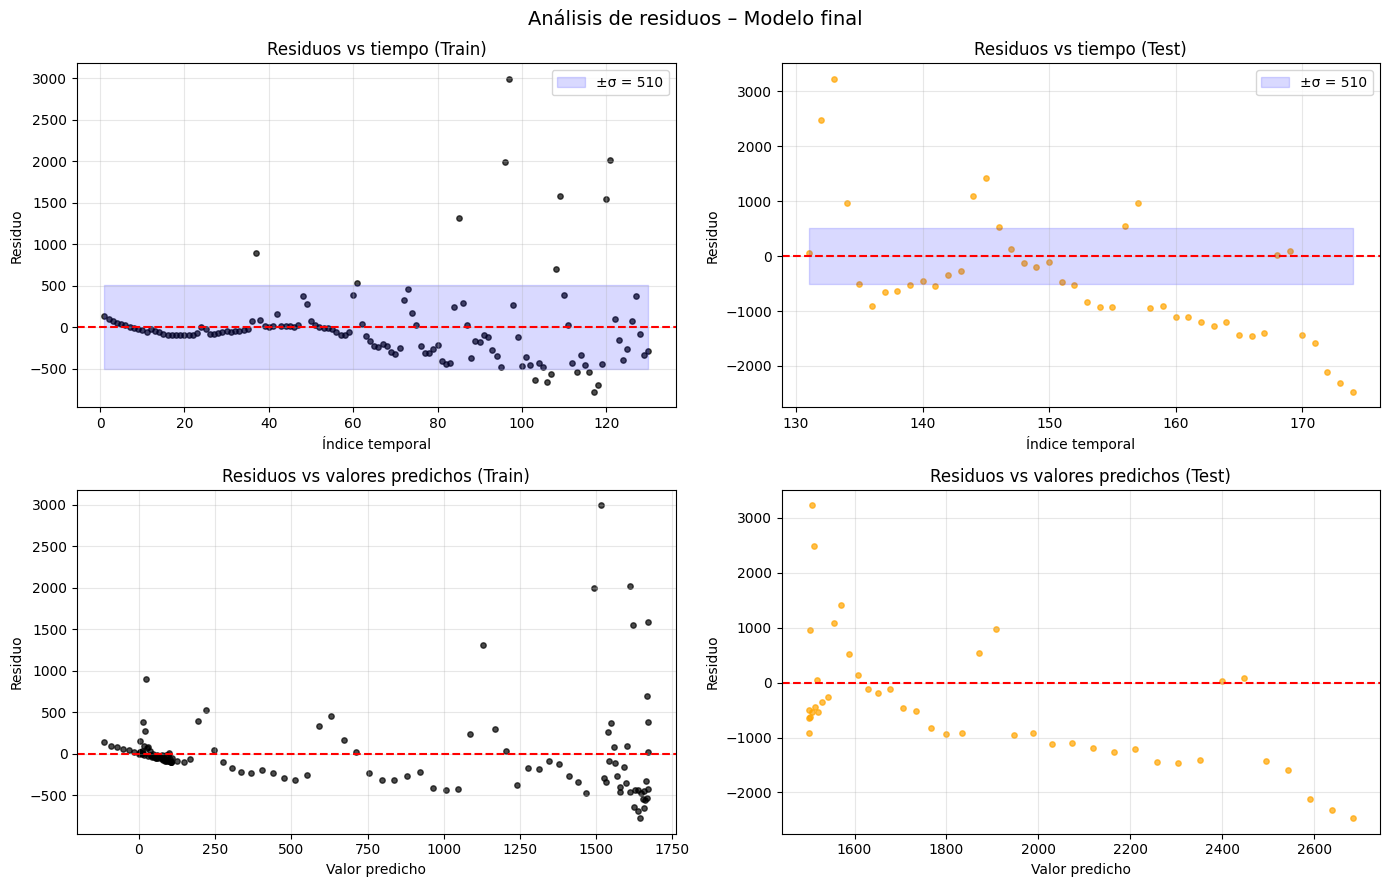

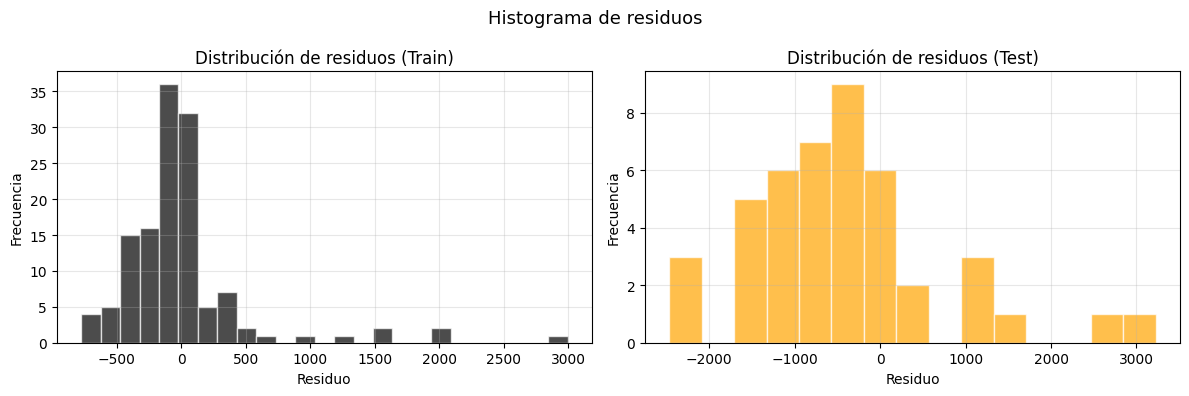


Resumen residuos TRAIN:
  Media   : -0.74
  Std     : 509.55
  Min/Max : -776.09 / 2994.20

Resumen residuos TEST:
  Media   : -441.09
  Std     : 1116.41
  Min/Max : -2467.29 / 3224.87


In [ ]:
# ANÁLISIS CRÍTICO

# Estimador MLE de sigma al cuadrado
y_pred_train = modelo_completo(x_train_norm, theta_opt_2)
residuos_train = y_train - y_pred_train

n_train = len(x_train)
sigma2_mle = np.sum(residuos_train**2) / n_train
sigma_mle  = np.sqrt(sigma2_mle)

print(f"Estimador MLE de σ²: {sigma2_mle:.2f}")
print(f"Estimador MLE de σ : {sigma_mle:.2f}")

# Residuos en TEST
y_pred_test_final = modelo_completo(x_test_norm, theta_opt_2)
residuos_test = y_test - y_pred_test_final

# Gráfico 1: Residuos en función del tiempo
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Panel superior izquierdo: residuos train vs tiempo
axes[0, 0].scatter(x_train, residuos_train, color='black', s=15, alpha=0.7)
axes[0, 0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0, 0].fill_between(x_train,
                         -sigma_mle, sigma_mle,
                         alpha=0.15, color='blue', label=f'±σ = {sigma_mle:.0f}')
axes[0, 0].set_title('Residuos vs tiempo (Train)')
axes[0, 0].set_xlabel('Índice temporal')
axes[0, 0].set_ylabel('Residuo')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Panel superior derecho: residuos test vs tiempo
axes[0, 1].scatter(x_test, residuos_test, color='orange', s=15, alpha=0.7)
axes[0, 1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0, 1].fill_between(x_test,
                         -sigma_mle, sigma_mle,
                         alpha=0.15, color='blue', label=f'±σ = {sigma_mle:.0f}')
axes[0, 1].set_title('Residuos vs tiempo (Test)')
axes[0, 1].set_xlabel('Índice temporal')
axes[0, 1].set_ylabel('Residuo')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Panel inferior izquierdo: residuos vs valores predichos (train)
axes[1, 0].scatter(y_pred_train, residuos_train, color='black', s=15, alpha=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1, 0].set_title('Residuos vs valores predichos (Train)')
axes[1, 0].set_xlabel('Valor predicho')
axes[1, 0].set_ylabel('Residuo')
axes[1, 0].grid(alpha=0.3)

# Panel inferior derecho: residuos vs valores predichos (test)
axes[1, 1].scatter(y_pred_test_final, residuos_test, color='orange', s=15, alpha=0.7)
axes[1, 1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1, 1].set_title('Residuos vs valores predichos (Test)')
axes[1, 1].set_xlabel('Valor predicho')
axes[1, 1].set_ylabel('Residuo')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Análisis de residuos – Modelo final', fontsize=14)
plt.tight_layout()
plt.show()

# Histograma de residuos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuos_train, bins=25, color='black', alpha=0.7, edgecolor='white')
axes[0].set_title('Distribución de residuos (Train)')
axes[0].set_xlabel('Residuo')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(alpha=0.3)

axes[1].hist(residuos_test, bins=15, color='orange', alpha=0.7, edgecolor='white')
axes[1].set_title('Distribución de residuos (Test)')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(alpha=0.3)

plt.suptitle('Histograma de residuos', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nResumen residuos TRAIN:")
print(f"  Media   : {residuos_train.mean():.2f}")
print(f"  Std     : {residuos_train.std():.2f}")
print(f"  Min/Max : {residuos_train.min():.2f} / {residuos_train.max():.2f}")

print(f"\nResumen residuos TEST:")
print(f"  Media   : {residuos_test.mean():.2f}")
print(f"  Std     : {residuos_test.std():.2f}")
print(f"  Min/Max : {residuos_test.min():.2f} / {residuos_test.max():.2f}")